In [1]:
import matplotlib.pyplot as plt
import torch
import numpy as np

# 1. Make a binary classification dataset with SkLearn `make_moons()`

In [2]:
from sklearn.datasets import make_moons
X, y = make_moons(n_samples=1000, random_state=42, noise=0.15)
X[:5], y[:5]

(array([[-0.08156811,  0.48221119],
        [ 1.08733336, -0.38115925],
        [ 0.83172491, -0.13313471],
        [ 0.20033884, -0.50030007],
        [-0.82495264,  0.53952635]]),
 array([1, 1, 1, 1, 0]))

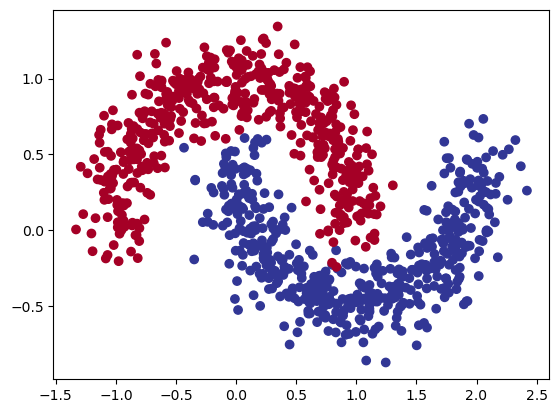

In [3]:
plt.scatter(X[:, 0], X[:, 1], c=y, cmap=plt.cm.RdYlBu)
plt.show();

In [4]:
from sklearn.model_selection import train_test_split
X, y = torch.from_numpy(X).type(torch.float64), torch.from_numpy(y).type(torch.float64)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)
X_train[:5], y_train[:5], len(X_train), len(X_test)

(tensor([[ 0.2117, -0.3144],
         [ 2.0156,  0.3054],
         [ 1.7078, -0.2087],
         [-0.5959,  0.7695],
         [-0.1047,  0.8017]], dtype=torch.float64),
 tensor([1., 1., 1., 0., 0.], dtype=torch.float64),
 800,
 200)

# 2. Create the Model

In [5]:
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

In [6]:
from torch import nn

class MoonModelV0(nn.Module):
    def __init__(self):
        super().__init__()
        self.layers = nn.Sequential(
            nn.Linear(in_features=2, out_features=16, dtype=torch.float64),
            nn.ReLU(),
            nn.Linear(in_features=16, out_features=8, dtype=torch.float64),
            nn.ReLU(),
            nn.Linear(in_features=8, out_features=1, dtype=torch.float64)
        )

    def forward(self, x):
        return self.layers(x)

model0 = MoonModelV0().to(device)
model0

MoonModelV0(
  (layers): Sequential(
    (0): Linear(in_features=2, out_features=16, bias=True)
    (1): ReLU()
    (2): Linear(in_features=16, out_features=8, bias=True)
    (3): ReLU()
    (4): Linear(in_features=8, out_features=1, bias=True)
  )
)

# 3. Create the Loss Function & Optimizer for the task

In [7]:
loss_fn = nn.BCEWithLogitsLoss()
optimizer = torch.optim.SGD(params=model0.parameters(), lr=0.01)

loss_fn, optimizer

(BCEWithLogitsLoss(),
 SGD (
 Parameter Group 0
     dampening: 0
     differentiable: False
     foreach: None
     fused: None
     lr: 0.01
     maximize: False
     momentum: 0
     nesterov: False
     weight_decay: 0
 ))

# 4. Create the Training & Testing Loop for the model

In [8]:
X_train, X_test = X_train.to(device), X_test.to(device)
y_train, y_test = y_train.to(device), y_test.to(device)

In [9]:
model0.eval()
with torch.inference_mode():
    y_logits = model0(X_test[:5]).squeeze()
print(y_logits)

y_probs = torch.sigmoid(y_logits)
print(y_probs)

y_preds = torch.round(y_probs)
print(y_preds)
print(y_test[:5])

tensor([-0.2471, -0.2784, -0.2023, -0.2606, -0.2681], device='cuda:0',
       dtype=torch.float64)
tensor([0.4385, 0.4308, 0.4496, 0.4352, 0.4334], device='cuda:0',
       dtype=torch.float64)
tensor([0., 0., 0., 0., 0.], device='cuda:0', dtype=torch.float64)
tensor([0., 1., 0., 0., 1.], device='cuda:0', dtype=torch.float64)


In [10]:
from torchmetrics.classification import Accuracy

acc_fn = Accuracy(task="binary").to(device)
acc_fn(y_preds, y_test[:5])

tensor(0.6000, device='cuda:0')

In [11]:
epochs = 15000

epoch_count = []
train_losses = []
test_losses = []
train_accs = []
test_accs = []



for epoch in range(epochs):
    model0.train()
    y_logits = model0(X_train).squeeze()
    y_preds = torch.round(torch.sigmoid(y_logits))
    loss = loss_fn(y_logits, y_train)
    acc = acc_fn(y_preds, y_train)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if epoch % int(epochs * 0.1) == 0 or epoch == epochs-1:
        model0.eval()
        with torch.inference_mode():
            y_logits = model0(X_test).squeeze()
        y_preds = torch.round(torch.sigmoid(y_logits))
        test_loss = loss_fn(y_logits, y_test)
        test_acc = acc_fn(y_preds, y_test)
        
        epoch_count.append(epoch)
        train_losses.append(loss.item())
        test_losses.append(test_loss.item())
        train_accs.append(acc.item())
        test_accs.append(test_acc.item())

        print(f"Epoch: {epoch}")
        print(f"\tTrain Loss: {loss} | Test Loss: {test_loss}")
        print(f"\tTrain Accuracy: {acc} | Test Accuracy: {test_acc}")

Epoch: 0
	Train Loss: 0.7140924681372767 | Test Loss: 0.7131776546361743
	Train Accuracy: 0.5 | Test Accuracy: 0.5
Epoch: 1500
	Train Loss: 0.33280476907416784 | Test Loss: 0.396854313898491
	Train Accuracy: 0.8224999904632568 | Test Accuracy: 0.800000011920929
Epoch: 3000
	Train Loss: 0.24082283430573506 | Test Loss: 0.2928480000041506
	Train Accuracy: 0.8949999809265137 | Test Accuracy: 0.8650000095367432
Epoch: 4500
	Train Loss: 0.19867596966394716 | Test Loss: 0.2475507954182951
	Train Accuracy: 0.918749988079071 | Test Accuracy: 0.8849999904632568
Epoch: 6000
	Train Loss: 0.14567651404293278 | Test Loss: 0.18829967171997516
	Train Accuracy: 0.9412500262260437 | Test Accuracy: 0.9049999713897705
Epoch: 7500
	Train Loss: 0.09478984148292348 | Test Loss: 0.12648328681413898
	Train Accuracy: 0.9737499952316284 | Test Accuracy: 0.9399999976158142
Epoch: 9000
	Train Loss: 0.06403565200615094 | Test Loss: 0.087659808458677
	Train Accuracy: 0.9850000143051147 | Test Accuracy: 0.9599999785

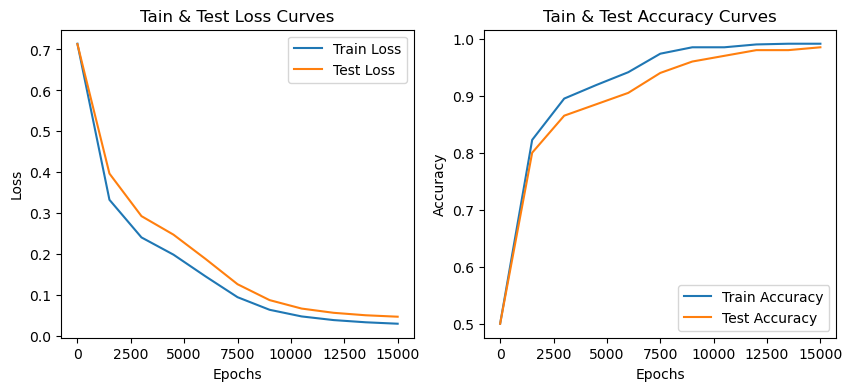

In [12]:
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(epoch_count, train_losses, label="Train Loss")
plt.plot(epoch_count, test_losses, label="Test Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Tain & Test Loss Curves") 
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(epoch_count, train_accs, label="Train Accuracy")
plt.plot(epoch_count, test_accs, label="Test Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Tain & Test Accuracy Curves") 
plt.legend()

plt.show();

# 5. Plot the predictions to see the models learning

In [13]:
# Plot the model predictions
import numpy as np

def plot_decision_boundary(model, X, y):
  
    # Put everything to CPU (works better with NumPy + Matplotlib)
    model.to("cpu")
    X, y = X.to("cpu"), y.to("cpu")

    # Source - https://madewithml.com/courses/foundations/neural-networks/ 
    # (with modifications)
    x_min, x_max = X[:, 0].min() - 0.1, X[:, 0].max() + 0.1
    y_min, y_max = X[:, 1].min() - 0.1, X[:, 1].max() + 0.1
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 101), 
                         np.linspace(y_min, y_max, 101))

    # Make features
    X_to_pred_on = torch.from_numpy(np.column_stack((xx.ravel(), yy.ravel()))).type(torch.float64)

    # Make predictions
    model.eval()
    with torch.inference_mode():
        y_logits = model(X_to_pred_on)

    # Test for multi-class or binary and adjust logits to prediction labels
    if len(torch.unique(y)) > 2:
        y_pred = torch.softmax(y_logits, dim=1).argmax(dim=1) # mutli-class
    else: 
        y_pred = torch.round(torch.sigmoid(y_logits)) # binary
    
    # Reshape preds and plot
    y_pred = y_pred.reshape(xx.shape).detach().numpy()
    plt.contourf(xx, yy, y_pred, cmap=plt.cm.RdYlBu, alpha=0.7)
    plt.scatter(X[:, 0], X[:, 1], c=y, s=40, cmap=plt.cm.RdYlBu)
    plt.xlim(xx.min(), xx.max())
    plt.ylim(yy.min(), yy.max())

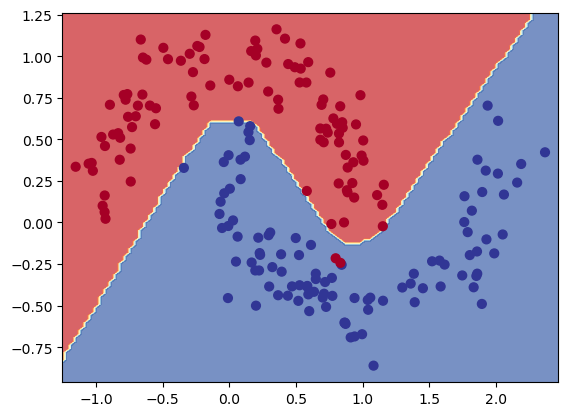

In [14]:
plot_decision_boundary(model0, X_test, y_test)

# 6. Replicate the Tanh (hyperbolic tangent) activation functions in PyTorch

In [15]:
x = torch.arange(-5, 6, 1)
x

tensor([-5, -4, -3, -2, -1,  0,  1,  2,  3,  4,  5])

In [16]:
y = torch.tanh(x)
y

tensor([-0.9999, -0.9993, -0.9951, -0.9640, -0.7616,  0.0000,  0.7616,  0.9640,
         0.9951,  0.9993,  0.9999])

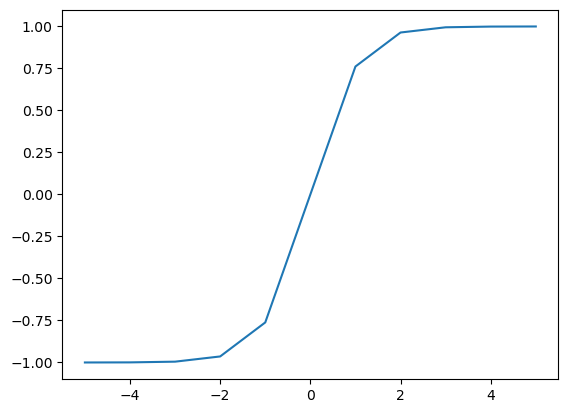

In [17]:
plt.plot(x, y)

In [18]:
def tanh_fn(x):
    return (torch.exp(x) - torch.exp(-x)) / (torch.exp(x) + torch.exp(-x))

y_2 = tanh_fn(x)

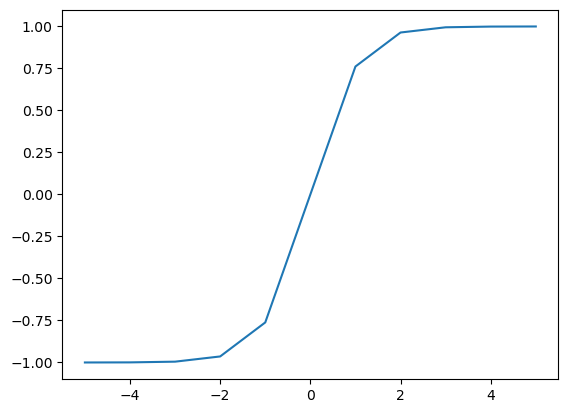

In [19]:
plt.plot(x, y_2)

# 7. Create a multi-class dataset using Spiral data creation frunction from CS231n

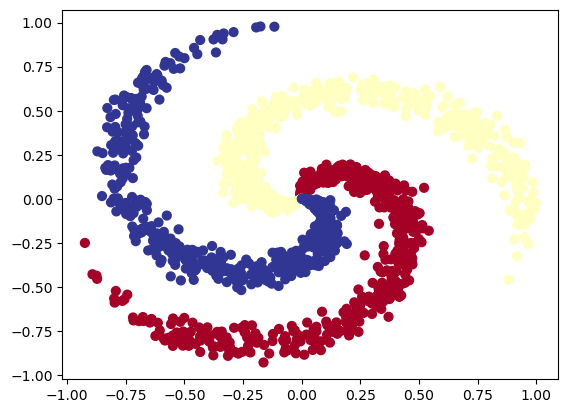

In [20]:
import numpy as np
import matplotlib.pyplot as plt
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
N = 500 # number of points per class
D = 2 # dimensionality
K = 3 # number of classes
X = np.zeros((N*K,D)) # data matrix (each row = single example)
y = np.zeros(N*K, dtype='uint8') # class labels
for j in range(K):
  ix = range(N*j,N*(j+1))
  r = np.linspace(0.0,1,N) # radius
  t = np.linspace(j*4,(j+1)*4,N) + np.random.randn(N)*0.2 # theta
  X[ix] = np.c_[r*np.sin(t), r*np.cos(t)]
  y[ix] = j
# lets visualize the data
plt.scatter(X[:, 0], X[:, 1], c=y, s=40, cmap=plt.cm.RdYlBu)
plt.show()

In [21]:
X = torch.from_numpy(X).type(torch.float) # features as float32
y = torch.from_numpy(y).type(torch.LongTensor) # labels need to be of type long

X_train, X_test, y_train, y_test = train_test_split(X, y)
len(X_train), len(X_test), X_train[:2], y_train[:2]

(1125,
 375,
 tensor([[-0.7194, -0.6743],
         [ 0.9113,  0.0908]]),
 tensor([0, 1]))

In [22]:
acc_fn = Accuracy(task="multiclass", num_classes=4).to(device)
acc_fn

MulticlassAccuracy()

In [23]:
class SpiralModelV0(nn.Module):
    def __init__(self):
        super().__init__()
        self.layers = nn.Sequential(
            nn.Linear(in_features=2, out_features=12),
            nn.ReLU(),
            nn.Linear(in_features=12, out_features=9),
            nn.ReLU(),
            nn.Linear(in_features=9, out_features=6),
            nn.ReLU(),
            nn.Linear(in_features=6, out_features=3),
        )

    def forward(self, x):
        return self.layers(x)


model1 = SpiralModelV0().to(device)
model1

SpiralModelV0(
  (layers): Sequential(
    (0): Linear(in_features=2, out_features=12, bias=True)
    (1): ReLU()
    (2): Linear(in_features=12, out_features=9, bias=True)
    (3): ReLU()
    (4): Linear(in_features=9, out_features=6, bias=True)
    (5): ReLU()
    (6): Linear(in_features=6, out_features=3, bias=True)
  )
)

In [24]:
X_train, X_test = X_train.to(device), X_test.to(device)
y_train, y_test = y_train.to(device), y_test.to(device)

In [25]:
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(params=model1.parameters(), lr=0.01)

loss_fn, optimizer

(CrossEntropyLoss(),
 SGD (
 Parameter Group 0
     dampening: 0
     differentiable: False
     foreach: None
     fused: None
     lr: 0.01
     maximize: False
     momentum: 0
     nesterov: False
     weight_decay: 0
 ))

In [26]:
model1.eval()
with torch.inference_mode():
    y_logits = model1(X_test[:5]).squeeze()
print(y_logits)

y_probs = torch.softmax(y_logits, dim=1)
print(y_probs)

y_preds = torch.argmax(y_probs, dim=1)
print(y_preds)
print(y_test[:5])

loss = loss_fn(y_logits, y_test[:5])
print(loss)

acc = acc_fn(y_preds, y_test[:5])
print(acc)

tensor([[-0.3151,  0.3435,  0.0454],
        [-0.3115,  0.3449,  0.0449],
        [-0.3297,  0.3522,  0.0586],
        [-0.3327,  0.3534,  0.0609],
        [-0.3187,  0.3478,  0.0503]], device='cuda:0')
tensor([[0.2290, 0.4425, 0.3284],
        [0.2296, 0.4426, 0.3279],
        [0.2246, 0.4442, 0.3312],
        [0.2238, 0.4445, 0.3317],
        [0.2276, 0.4432, 0.3292]], device='cuda:0')
tensor([1, 1, 1, 1, 1], device='cuda:0')
tensor([2, 1, 0, 2, 1], device='cuda:0')
tensor(1.0678, device='cuda:0')
tensor(0.4000, device='cuda:0')


In [27]:
epochs = 15000

losses = [[], []]
accs = [[], []]

for epoch in range(epochs):
    model1.train()
    y_logits = model1(X_train).squeeze()
    y_preds = torch.argmax(torch.softmax(y_logits, dim=1), dim=1)
    loss = loss_fn(y_logits, y_train)
    acc = acc_fn(y_preds, y_train)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    model1.eval()
    with torch.inference_mode():
        y_logits = model1(X_test).squeeze()
    y_preds = torch.argmax(torch.softmax(y_logits, dim=1), dim=1)
    test_loss = loss_fn(y_logits, y_test)
    test_acc = acc_fn(y_preds, y_test)
    
    losses[0].append(loss.item())
    losses[1].append(test_loss.item())
    accs[0].append(acc.item())
    accs[1].append(test_acc.item())

    if epoch % int(epochs * 0.1) == 0 or epoch == epochs-1:
        print(f"Epoch: {epoch}")
        print(f"\tTrain Loss: {loss} | Test Loss: {test_loss}")
        print(f"\tTrain Accuracy: {acc} | Test Accuracy: {test_acc}")

Epoch: 0
	Train Loss: 1.1454498767852783 | Test Loss: 1.1266124248504639
	Train Accuracy: 0.3235555589199066 | Test Accuracy: 0.36266666650772095
Epoch: 1500
	Train Loss: 1.062172532081604 | Test Loss: 1.0662301778793335
	Train Accuracy: 0.5164444446563721 | Test Accuracy: 0.4906666576862335
Epoch: 3000
	Train Loss: 0.964363157749176 | Test Loss: 0.9660518169403076
	Train Accuracy: 0.47200000286102295 | Test Accuracy: 0.4320000112056732
Epoch: 4500
	Train Loss: 0.9159452319145203 | Test Loss: 0.9162537455558777
	Train Accuracy: 0.5208888649940491 | Test Accuracy: 0.5120000243186951
Epoch: 6000
	Train Loss: 0.7395798563957214 | Test Loss: 0.7322211861610413
	Train Accuracy: 0.7333333492279053 | Test Accuracy: 0.7279999852180481
Epoch: 7500
	Train Loss: 0.425599068403244 | Test Loss: 0.42957019805908203
	Train Accuracy: 0.8346666693687439 | Test Accuracy: 0.8293333053588867
Epoch: 9000
	Train Loss: 0.2555186152458191 | Test Loss: 0.26646846532821655
	Train Accuracy: 0.9208889007568359 | 

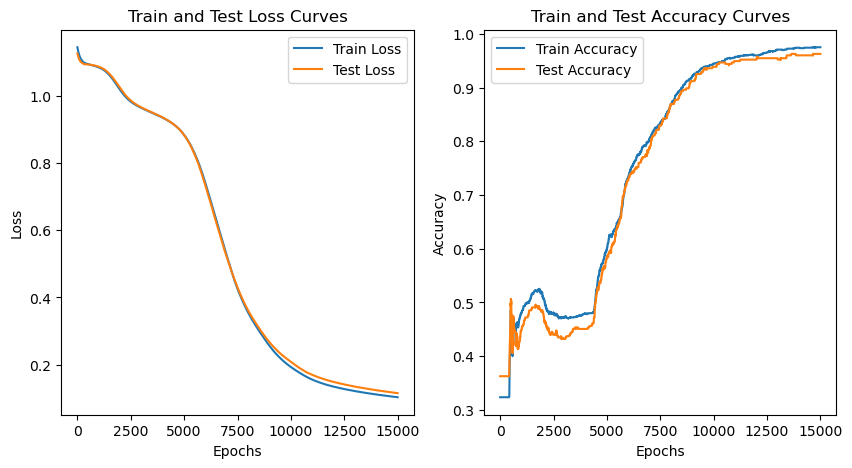

In [28]:
x = range(epochs)

plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.plot(x, losses[0], label="Train Loss")
plt.plot(x, losses[1], label="Test Loss")
plt.title("Train and Test Loss Curves")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(x, accs[0], label="Train Accuracy")
plt.plot(x, accs[1], label="Test Accuracy")
plt.title("Train and Test Accuracy Curves")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()

plt.show();

In [29]:
# Plot the model predictions
import numpy as np

def plot_decision_boundary(model, X, y):
  
    # Put everything to CPU (works better with NumPy + Matplotlib)
    model.to("cpu")
    X, y = X.to("cpu"), y.to("cpu")

    # Source - https://madewithml.com/courses/foundations/neural-networks/ 
    # (with modifications)
    x_min, x_max = X[:, 0].min() - 0.1, X[:, 0].max() + 0.1
    y_min, y_max = X[:, 1].min() - 0.1, X[:, 1].max() + 0.1
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 101), 
                         np.linspace(y_min, y_max, 101))

    # Make features
    X_to_pred_on = torch.from_numpy(np.column_stack((xx.ravel(), yy.ravel()))).type(torch.float32)

    # Make predictions
    model.eval()
    with torch.inference_mode():
        y_logits = model(X_to_pred_on)

    # Test for multi-class or binary and adjust logits to prediction labels
    if len(torch.unique(y)) > 2:
        y_pred = torch.softmax(y_logits, dim=1).argmax(dim=1) # mutli-class
    else: 
        y_pred = torch.round(torch.sigmoid(y_logits)) # binary
    
    # Reshape preds and plot
    y_pred = y_pred.reshape(xx.shape).detach().numpy()
    plt.contourf(xx, yy, y_pred, cmap=plt.cm.RdYlBu, alpha=0.7)
    plt.scatter(X[:, 0], X[:, 1], c=y, s=40, cmap=plt.cm.RdYlBu)
    plt.xlim(xx.min(), xx.max())
    plt.ylim(yy.min(), yy.max())

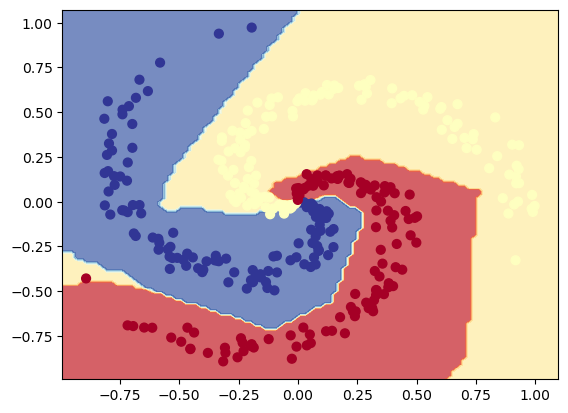

In [30]:
plot_decision_boundary(model1, X_test, y_test)